In [ ]:
!pip install -q pytorch-lightning
!pip install -q roboflow

In [ ]:
!pip uninstall transformers -y

In [ ]:
!pip install transformers==4.37.0

In [ ]:
import transformers
print(transformers.__version__)

4.37.0


In [ ]:
from huggingface_hub import login
from google.colab import userdata
token = userdata.get('Nyi_token')
login(token=token)

In [ ]:
import os
import random
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch
import torchvision
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pycocotools.coco import COCO
from transformers import DetaImageProcessor, DetaForObjectDetection
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Hugging Face

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [ ]:
class CocoDetection(torchvision.datasets.CocoDetection):
    def __init__(self, img_folder, feature_extractor, train=True):
        ann_file = os.path.join(img_folder, "_annotations.coco.json")
        super(CocoDetection, self).__init__(img_folder, ann_file)
        self.feature_extractor = feature_extractor

    def __getitem__(self, idx):
        # read in PIL image and target in COCO format
        img, target = super(CocoDetection, self).__getitem__(idx)

        # preprocess image and target (converting target to DETR format, resizing + normalization of both image and target)
        image_id = self.ids[idx]
        target = {'image_id': image_id, 'annotations': target}
        encoding = self.feature_extractor(images=img, annotations=target, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze() # remove batch dimension
        target = encoding["labels"][0] # remove batch dimension

        return pixel_values, target

In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/CircuitRecognitioncoco/train")
count_images("datasets/CircuitRecognitioncoco/valid")

Total images: 2652
Total images: 400


In [ ]:
# Check train annotations
with open("datasets/CircuitRecognitioncoco/train/_annotations.coco.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/CircuitRecognitioncoco/valid/_annotations.coco.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 2652
Train annotations: 14749
Categories: [{'id': 0, 'name': 'Predict-circuit-parameters', 'supercategory': 'none'}, {'id': 1, 'name': 'acv', 'supercategory': 'Predict-circuit-parameters'}, {'id': 2, 'name': 'c', 'supercategory': 'Predict-circuit-parameters'}, {'id': 3, 'name': 'i', 'supercategory': 'Predict-circuit-parameters'}, {'id': 4, 'name': 'l', 'supercategory': 'Predict-circuit-parameters'}, {'id': 5, 'name': 'r', 'supercategory': 'Predict-circuit-parameters'}, {'id': 6, 'name': 'v', 'supercategory': 'Predict-circuit-parameters'}]

Valid images: 400
Valid annotations: 2208


In [ ]:
feature_extractor = DetaImageProcessor.from_pretrained("jozhang97/deta-resnet-50", use_fast=False, min_size=384, max_size=512)

train_dataset = CocoDetection(img_folder=("datasets/CircuitRecognitioncoco/train"), feature_extractor=feature_extractor)
val_dataset = CocoDetection(img_folder=("datasets/CircuitRecognitioncoco/valid"), feature_extractor=feature_extractor, train=False)

print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(val_dataset))

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Number of training examples: 2652
Number of validation examples: 400


Image ID : 1216


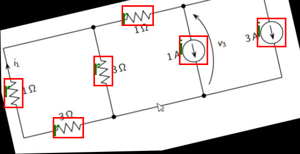

In [ ]:
image_ids = train_dataset.coco.getImgIds()
image_id = image_ids[np.random.randint(0, len(image_ids))]
print('Image ID : {}'.format(image_id))
image = train_dataset.coco.loadImgs(image_id)[0]
image = Image.open(os.path.join("datasets/CircuitRecognitioncoco/train", image['file_name']))

annotations = train_dataset.coco.imgToAnns[image_id]
draw = ImageDraw.Draw(image, "RGBA")

cats = train_dataset.coco.cats
id2label = {k: v['name'] for k,v in cats.items()}

font_path = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"
font = ImageFont.truetype(font_path, 40) # Increased font size for better visibility

for annotation in annotations:
  box = annotation['bbox']
  class_idx = annotation['category_id']
  x,y,w,h = tuple(box)
  draw.rectangle((x,y,x+w,y+h), outline='red', width=3)
  draw.text((x, y), id2label[class_idx], fill='green', font=font)

width, height = image.size
target_width = 300
ratio = target_width / width
target_height = int(height * ratio)

image.resize((target_width, target_height))

In [ ]:
def collate_fn(batch):
  pixel_values = [item[0] for item in batch]
  encoding = feature_extractor.pad(pixel_values, return_tensors="pt")
  labels = [item[1] for item in batch]
  batch = {}
  batch['pixel_values'] = encoding['pixel_values']
  batch['labels'] = labels
  return batch

train_dataloader = DataLoader(train_dataset, collate_fn=collate_fn, batch_size=1, num_workers=1, shuffle=True)
val_dataloader = DataLoader(val_dataset, collate_fn=collate_fn, batch_size=1, num_workers=1, shuffle=False)
batch = next(iter(train_dataloader))

In [ ]:
class Deta(pl.LightningModule):

     def __init__(self, lr, weight_decay):
         super().__init__()
         # replace COCO classification head with custom head
         self.model = DetaForObjectDetection.from_pretrained("jozhang97/deta-resnet-50",
                                                             num_labels=len(id2label),
                                                             auxiliary_loss=True,
                                                             ignore_mismatched_sizes=True)

         self.lr = lr
         self.weight_decay = weight_decay
         self.save_hyperparameters()  # adding this will save the hyperparameters to W&B too

     def forward(self, pixel_values):
       outputs = self.model(pixel_values=pixel_values)

       return outputs

     def common_step(self, batch, batch_idx):
       pixel_values = batch["pixel_values"]
       labels = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]

       outputs = self.model(pixel_values=pixel_values, labels=labels)

       loss = outputs.loss
       loss_dict = outputs.loss_dict

       return loss, loss_dict

     def training_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        # logs metrics for each training_step,
        # and the average across the epoch
        self.log("train/loss", loss)
        for k,v in loss_dict.items():
          self.log("train/" + k, v.item())

        return loss

     def validation_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        self.log("validation/loss", loss)
        for k,v in loss_dict.items():
          self.log("validation/" + k, v.item())

        return loss

     def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr,
                                  weight_decay=self.weight_decay)

        return optimizer

     def train_dataloader(self):
        return train_dataloader

     def val_dataloader(self):
        return val_dataloader

In [ ]:
print(len(id2label))

7


In [ ]:
#initialize the model
model = Deta(lr=2.5e-5, weight_decay=1e-4).train()

In [ ]:
# Keep track of the checkpoint with the lowest validation loss
checkpoint_callback = ModelCheckpoint(
    monitor="validation/loss", mode="min",
    filename="ckpt_{epoch:03d}-vloss_{valid/loss:.4f}",
    auto_insert_metric_name=False,
)

In [ ]:
trainer = Trainer(accelerator='gpu', devices=1, max_epochs=2, gradient_clip_val=0.1, accumulate_grad_batches=8,
                 callbacks=[checkpoint_callback], log_every_n_steps=5) #  , logger=wandb_logger
trainer.fit(model)

# Resume
# trainer.fit(model, ckpt_path="lightning_logs/version_17/checkpoints/ckpt_001-vloss_0.0000.ckpt")

In [ ]:
# Epoch 1/1  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2652/2652 0:38:01 • 0:00:00 1.19it/s v_num: 17.000
# INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.

In [ ]:
# Get the path of the best saved model.
CKPT_PATH = checkpoint_callback.best_model_path
CKPT_PATH

'/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/lightning_logs/version_17/checkpoints/ckpt_001-vloss_0.0000.ckpt'

In [ ]:
CKPT_PATH = 'lightning_logs/version_17/checkpoints/ckpt_001-vloss_0.0000.ckpt'

In [ ]:
model = Deta.load_from_checkpoint(CKPT_PATH).eval()

In [ ]:
#clean up torch tensors
torch.cuda.empty_cache()

In [ ]:
from pycocotools.cocoeval import COCOeval
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

print("Running evaluation...")

all_results = []

for idx, batch in enumerate(tqdm(val_dataloader)):
    pixel_values = batch["pixel_values"].to(device)
    labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

    with torch.no_grad():
        outputs = model.model(pixel_values=pixel_values)

    orig_target_sizes = torch.stack([target["orig_size"] for target in labels], dim=0)
    results = feature_extractor.post_process_object_detection(outputs, target_sizes=orig_target_sizes, threshold=0.1)

    for target, result in zip(labels, results):
        image_id = target['image_id'].item()
        boxes = result['boxes'].cpu().numpy()
        scores = result['scores'].cpu().numpy()
        labels_pred = result['labels'].cpu().numpy()

        # Convert from xyxy to xywh format for COCO
        boxes_xywh = boxes.copy()
        boxes_xywh[:, 2] = boxes[:, 2] - boxes[:, 0]
        boxes_xywh[:, 3] = boxes[:, 3] - boxes[:, 1]

        for box, score, label in zip(boxes_xywh, scores, labels_pred):
            all_results.append({
                'image_id': image_id,
                'category_id': label.item(),
                'bbox': box.tolist(),
                'score': score.item(),
            })

# Run COCO evaluation
coco_gt = val_dataset.coco
coco_dt = coco_gt.loadRes(all_results)
coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

In [ ]:
'''
Running evaluation...
100%
 400/400 [02:30<00:00,  3.15it/s]
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.74s).
Accumulating evaluation results...
DONE (t=0.17s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.617
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.946
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.705
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.491
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.617
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.711
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.491
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.727
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.728
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.625
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.727
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.733
'''

In [ ]:
#we borrow the eval scripts from the DETR repo as they provide similar functionality to calculate mAP
!git clone https://github.com/facebookresearch/detr.git

fatal: destination path 'detr' already exists and is not an empty directory.


In [ ]:
%cd /content/gdrive/MyDrive/Hugging Face/detr

/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/detr


In [ ]:
from detr import *

In [ ]:
from detr.datasets import get_coco_api_from_dataset
base_ds = get_coco_api_from_dataset(val_dataset)
from detr.datasets.coco_eval import CocoEvaluator

In [ ]:
%cd /content/gdrive/MyDrive/Hugging Face/

/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [ ]:
from tqdm.notebook import tqdm

iou_types = ['bbox']
coco_evaluator = CocoEvaluator(base_ds, iou_types) # initialize evaluator with ground truths

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def post_process_predictions_for_coco(outputs, original_labels, threshold=0.5):
    """
    Prepares raw model outputs for COCO evaluation by converting them into the format
    expected by detr's coco_eval.py.

    Args:
        outputs (transformers.modeling_outputs.ObjectDetectionOutput): Raw outputs from the model.
        original_labels (list[dict]): The original labels from the batch, containing 'image_id' and 'orig_size'.
        threshold (float): Confidence threshold to filter predictions.
    Returns:
        dict: A dictionary where keys are image_ids and values are dictionaries containing
              'boxes' (normalized cxcywh tensors), 'scores' (tensors), and 'labels' (tensors).
              This is the input format expected by detr's `prepare_for_coco_detection` function.
    """
    pred_logits = outputs.logits
    pred_boxes = outputs.pred_boxes

    res = {} # This will store image_id -> {'boxes': tensor, 'scores': tensor, 'labels': tensor}
    for batch_idx in range(len(original_labels)):
        original_img_id = original_labels[batch_idx]['image_id'].item()
        original_img_size = original_labels[batch_idx]['orig_size'] # [height, width]
        img_h, img_w = original_img_size[0].item(), original_img_size[1].item()

        # Get probabilities, excluding the 'no object' class (last one)
        probas_all_queries = pred_logits[batch_idx].softmax(-1)
        probas_object_classes = probas_all_queries[:, :-1] # Exclude the last column (no object)

        # Keep predictions with confidence > threshold
        scores, labels = probas_object_classes.max(-1) # Max probability and corresponding class for each query
        keep = scores > threshold

        # Filter boxes, scores, and labels
        # Convert cxcywh to xyxy format as expected by COCOEvaluator
        boxes_filtered_normalized_xyxy = box_cxcywh_to_xyxy(pred_boxes[batch_idx, keep])

        # Rescale boxes to original image dimensions
        boxes_filtered_scaled_xyxy = boxes_filtered_normalized_xyxy * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32, device=boxes_filtered_normalized_xyxy.device)

        scores_filtered = scores[keep]
        labels_filtered = labels[keep]

        # Store in the format expected by detr's coco_eval.py
        res[original_img_id] = {
            'boxes': boxes_filtered_scaled_xyxy,
            'scores': scores_filtered,
            'labels': labels_filtered,
        }

    return res

print("Running evaluation...")

with torch.no_grad():
    for idx, batch in enumerate(tqdm(val_dataloader)):
        # get the inputs
        pixel_values = batch["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]] # These are the ground truth labels from the dataset

        # forward pass
        outputs = model.model(pixel_values=pixel_values)

        # Use the custom post-processing function
        # results_for_batch will be a dict: {image_id: {'boxes': tensor, 'scores': tensor, 'labels': tensor}}
        results_for_batch = post_process_predictions_for_coco(outputs, labels, threshold=0.1)

        results_for_batch = {
            img_id: {k: v.to("cpu") for k, v in res.items()}
            for img_id, res in results_for_batch.items()
        }

        # coco_evaluator.update expects a dict where keys are image_ids and values are dictionaries
        # containing 'boxes', 'scores', 'labels' tensors. This format is now produced by our function.
        coco_evaluator.update(results_for_batch)

coco_evaluator.synchronize_between_processes()
coco_evaluator.accumulate()
coco_evaluator.summarize()

In [ ]:
'''
Running evaluation...
100%
 400/400 [02:32<00:00,  3.02it/s]
Accumulating evaluation results...
DONE (t=0.65s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.219
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.307
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.254
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.239
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.220
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.757
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.411
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.638
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.690
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.611
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.688
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.800
'''

In [ ]:
from tqdm.notebook import tqdm

iou_types = ['bbox']
coco_evaluator = CocoEvaluator(base_ds, iou_types) # initialize evaluator with ground truths

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

print("Running evaluation...")

with torch.no_grad():
    for idx, batch in enumerate(tqdm(val_dataloader)):
        # get the inputs
        pixel_values = batch["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]] # These are the ground truth labels from the dataset

        # forward pass
        outputs = model.model(pixel_values=pixel_values)

        orig_target_sizes = torch.stack([target["orig_size"] for target in labels], dim=0)
        results = feature_extractor.post_process_object_detection(outputs, threshold=0.1, target_sizes=orig_target_sizes)

        # 2. Move results to CPU to prevent GPU accumulation
        results = [{k: v.to("cpu") for k, v in result.items()} for result in results]

        res = {target['image_id'].item(): output for target, output in zip(labels, results)}
        coco_evaluator.update(res)

coco_evaluator.synchronize_between_processes()
coco_evaluator.accumulate()
coco_evaluator.summarize()

In [ ]:
'''
Running evaluation...
100%
 400/400 [02:48<00:00,  2.93it/s]
Accumulating evaluation results...
DONE (t=0.19s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.617
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.946
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.705
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.491
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.617
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.711
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.491
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.727
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.728
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.625
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.727
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.733
'''

In [ ]:
pixel_values, target = val_dataset[234]
pixel_values = pixel_values.unsqueeze(0).to(device)
outputs = model(pixel_values=pixel_values)

In [ ]:
results = feature_extractor.post_process_object_detection(
    outputs, target_sizes=torch.tensor([(image.height, image.width)]), threshold=0.3
)
result = results[0]
print(result)

{'scores': tensor([0.4744, 0.4680, 0.4609, 0.4550, 0.4026, 0.3408], device='cuda:0',
       grad_fn=<IndexBackward0>), 'labels': tensor([3, 3, 5, 5, 4, 2], device='cuda:0'), 'boxes': tensor([[387.2336, 181.7802, 438.5091, 233.8550],
        [144.7787, 170.7316, 195.8379, 222.2298],
        [245.0758, 255.4543, 274.1099, 315.0793],
        [141.3852,  28.0227, 200.2583,  57.0125],
        [136.5307, 356.7584, 203.7722, 389.6620],
        [ 58.5440, 272.3038, 106.5509, 298.3587]], device='cuda:0',
       grad_fn=<IndexBackward0>)}


In [ ]:
import torch
import matplotlib.pyplot as plt

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

def plot_results(pil_img, scores, labels, boxes):
    plt.figure(figsize=(6,6))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for score, label, (xmin, ymin, xmax, ymax), c in zip(scores.tolist(), labels.tolist(), boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        text = f'{id2label[label]}: {score:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

def visualize_predictions(image, outputs, threshold=0.9):
  # post-process outputs
  target_sizes = torch.tensor(image.size[::-1]).unsqueeze(0).to(outputs.logits.device)
  results = feature_extractor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=threshold)[0]
  print(results)
  # plot results
  plot_results(image, results['scores'].cpu(), results['labels'].cpu(), results['boxes'].cpu())

In [ ]:
pixel_values, target = val_dataset[234]
pixel_values = pixel_values.unsqueeze(0).to(device)
outputs = model(pixel_values=pixel_values)

{'scores': tensor([0.4744, 0.4680, 0.4609, 0.4550, 0.4026, 0.3408], device='cuda:0',
       grad_fn=<IndexBackward0>), 'labels': tensor([3, 3, 5, 5, 4, 2], device='cuda:0'), 'boxes': tensor([[387.2336, 181.7802, 438.5091, 233.8550],
        [144.7787, 170.7316, 195.8379, 222.2298],
        [245.0758, 255.4543, 274.1099, 315.0793],
        [141.3852,  28.0227, 200.2583,  57.0125],
        [136.5307, 356.7584, 203.7722, 389.6620],
        [ 58.5440, 272.3038, 106.5509, 298.3587]], device='cuda:0',
       grad_fn=<IndexBackward0>)}


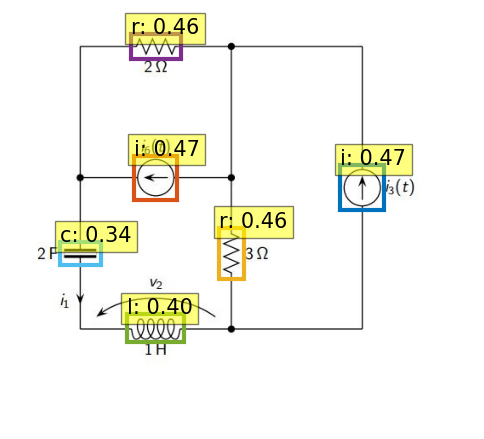

In [ ]:
image_id = target['image_id'].item()
image = val_dataset.coco.loadImgs(image_id)[0]
image = Image.open(os.path.join("datasets/CircuitRecognitioncoco/valid", image['file_name']))

visualize_predictions(image, outputs, threshold=0.3)

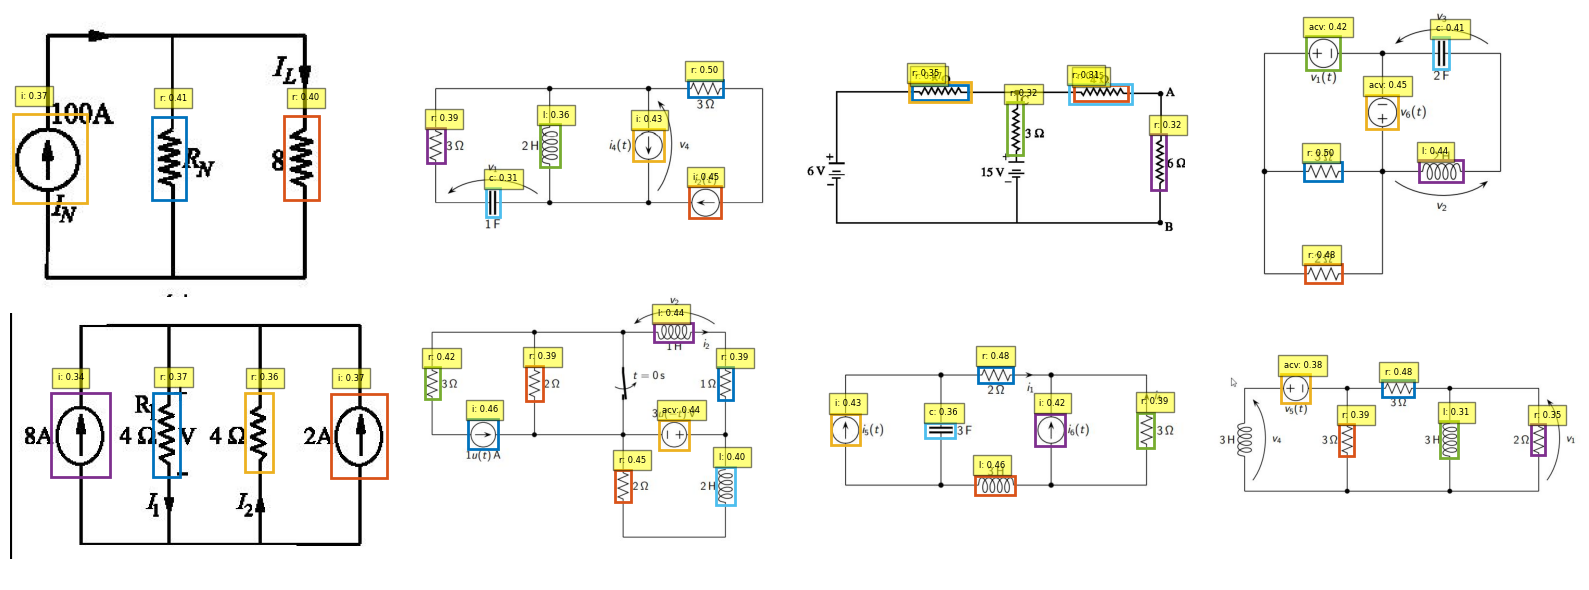

In [ ]:
# ---------------- CONFIG ----------------
val_dir = "datasets/CircuitRecognitioncoco/valid"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image_path in enumerate(sample_imgs):
    plt.subplot(rows, cols, ii + 1)

    # Load image using PIL for consistency with feature_extractor
    pil_img = Image.open(image_path).convert("RGB")

    # prepare image for the model
    inputs = feature_extractor(images=pil_img, return_tensors="pt")

    # Move inputs to the device
    inputs = inputs['pixel_values'].to(device)

    # forward pass (no need for gradients at inference time)
    with torch.no_grad():
        outputs = model(inputs)

        target_sizes = torch.tensor(pil_img.size[::-1]).unsqueeze(0).to(outputs.logits.device)
        results = feature_extractor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.3)[0]

        scores = results['scores'].cpu()
        labels = results['labels'].cpu()
        boxes = results['boxes'].cpu()

        ax = plt.gca()
        # Draw the original image first
        ax.imshow(pil_img)

        colors = COLORS * 100
        for score, label, (xmin, ymin, xmax, ymax), c in zip(scores.tolist(), labels.tolist(), boxes.tolist(), colors):
            ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                      fill=False, color=c, linewidth=2))
            text = f'{id2label[label]}: {score:0.2f}'
            ax.text(xmin +6, ymin -12, text, fontsize=6,
                    bbox=dict(facecolor='yellow', alpha=0.5))

    plt.axis('off')

plt.tight_layout()
plt.show()